# Lab 1
## Dynamic model of a multi-link manipulator

## Steps

### 0. Import the necessary libraries

In [24]:
from math import pi
import numpy as np
import roboticstoolbox as rtb
import matplotlib.pyplot as plt

### 1. Import robot model (Franka Emika Panda Robot)

In [25]:
robot = rtb.models.DH.Panda()
print(robot)

DHRobot: Panda (by Franka Emika), 7 joints (RRRRRRR), dynamics, geometry, modified DH parameters
┌─────────┬────────┬─────┬───────┬─────────┬────────┐
│  aⱼ₋₁   │  ⍺ⱼ₋₁  │ θⱼ  │  dⱼ   │   q⁻    │   q⁺   │
├─────────┼────────┼─────┼───────┼─────────┼────────┤
│     0.0 │   0.0° │  q1 │ 0.333 │ -166.0° │ 166.0° │
│     0.0 │ -90.0° │  q2 │   0.0 │ -101.0° │ 101.0° │
│     0.0 │  90.0° │  q3 │ 0.316 │ -166.0° │ 166.0° │
│  0.0825 │  90.0° │  q4 │   0.0 │ -176.0° │  -4.0° │
│ -0.0825 │ -90.0° │  q5 │ 0.384 │ -166.0° │ 166.0° │
│     0.0 │  90.0° │  q6 │   0.0 │   -1.0° │ 215.0° │
│   0.088 │  90.0° │  q7 │ 0.107 │ -166.0° │ 166.0° │
└─────────┴────────┴─────┴───────┴─────────┴────────┘

┌──────┬───────────────────────────────────────┐
│ tool │ t = 0, 0, 0.1; rpy/xyz = -45°, 0°, 0° │
└──────┴───────────────────────────────────────┘

┌──────┬─────┬────────┬─────┬───────┬─────┬───────┬──────┐
│ name │ q0  │ q1     │ q2  │ q3    │ q4  │ q5    │ q6   │
├──────┼─────┼────────┼─────┼───────┼─────

### 2. Fill in the parameters of the robot model for Franka Emika Panda Robot
the dynamic parameters come from this paper https://inria.hal.science/hal-02265294/file/IROS_19_Panda-SuppMaterial.pdf

In the standard Lagrangian formulation of rigid-body robot dynamics, the equation of motion is:

$$M(q)\ddot{q} + C(q, \dot{q})\dot{q} + G(q) = \tau$$

**Where:**
*   $q, \dot{q}, \ddot{q}$ : Joint positions, velocities, and accelerations ($n \times 1$).
*   $M(q)$ : $n \times n$ symmetric positive-definite **Inertia Matrix**.
*   $C(q, \dot{q})$ : $n \times n$ **Coriolis/centrifugal Matrix**.
*   $G(q)$ : $n \times 1$ **Gravity torque vector**.
*   $\tau$ : $n \times 1$ applied joint torques.

---

0. Using dyn() you can view the dynamic parameters of each link

In [26]:
print(robot.links[0].dyn())  # initial dynamic parameters of the first link

m     =         5 
r     =         0        0        0 
        |      0.7 -0.00014   0.0068 | 
I     = | -0.00014     0.71    0.019 | 
        |   0.0068    0.019   0.0091 | 
Jm    =         0 
B     =         0 
Tc    =         0(+)        0(-) 
G     =         1 
qlim  =      -2.9 to      2.9


#### 1. Let's define the mass of the links 

### The link mass $m_i$ appears in TWO fundamental ways:

#### a. INERTIA TERM $M(q)$:
The total kinetic energy of link $i$ is:
$$K_i = \frac{1}{2} (m_i v_{ci}^T v_{ci} + \omega_i^T I_i \omega_i)$$
Where $v_{ci}$ is the linear velocity of the center of mass and $I_i$ is the inertia tensor. The mass $m_i$ directly scales the translational part of the kinetic energy, contributing to the $M(q)$ matrix via the linear velocity Jacobian:
$$M_{trans,i} = m_i J_{v,i}^T J_{v,i}$$

#### b. GRAVITY TERM $G(q)$:
The potential energy of link $i$ is:
$$P_i = -m_i g^T p_{ci}$$
Where $g$ is the gravity vector (e.g., $[0; 0; -9.81]$) and $p_{ci}$ is the position of the link's center of mass. The gravity torque is the gradient of total potential energy:
$$G(q) = \frac{\partial P}{\partial q}$$
Therefore, each link mass $m_i$ linearly scales the gravity loading on the joints that support it.

In [27]:
robot.links[0].m = 4.9707
robot.links[1].m = 0.6469
robot.links[2].m = 3.2286
robot.links[3].m = 3.5879
robot.links[4].m = 1.2259
robot.links[5].m = 1.6666
robot.links[6].m = 0.7355

2. Let's define the center of mass of each link

The center of mass (CoM) is the unique point where the weighted relative position of the distributed mass sums to zero. In the dynamics equation, it is primarily used to determine the **Gravity Vector $G(q)$**.

The vector $r_{ci} = [x_{ci}, y_{ci}, z_{ci}]^T$ defines the position of the CoM relative to the origin of link frame $\{i\}$.


In [28]:
robot.links[0].r = [0.0039, 0.0021, -0.0477]
robot.links[1].r = [-0.0031, -0.0287, 0.0035]
robot.links[2].r = [0.0275, 0.0393, -0.0665]
robot.links[3].r = [-0.0532, 0.1044, 0.0275]
robot.links[4].r = [-0.0120, 0.0411, -0.0384]
robot.links[5].r = [0.0601, -0.0141, -0.0105]
robot.links[6].r = [0.0105, -0.0043, 0.0616]

3. Let's define the inertia tensor of each link. Filling: [Lxx, Lyy, Lzz, Lxy, Lyz, Lxz]

The inertia tensor $I_i$ is a $3 \times 3$ symmetric matrix that describes the distribution of a link's mass relative to its center of mass. It defines how much torque is required to achieve a specific angular acceleration about each axis.

$$I_i = \begin{bmatrix} I_{xx} & I_{xy} & I_{xz} \\ I_{xy} & I_{yy} & I_{yz} \\ I_{xz} & I_{yz} & I_{zz} \end{bmatrix}$$

In [29]:
robot.links[0].I = [0.70337, 0.70620, 0.00911, -0.00014, 0.01916, 0.00677]
robot.links[1].I = [0.00796, 0.02811, 0.00259, -0.00392, 0.00070, 0.01025]
robot.links[2].I = [0.03724, 0.03615, 0.01083, -0.00476, -0.01280, -0.01139]
robot.links[3].I = [0.02585, 0.01955, 0.02832, 0.00779, 0.00864, -0.00133]
robot.links[4].I = [0.03554, 0.02947, 0.00862, -0.00211, 0.00229, -0.00403]
robot.links[5].I = [0.00196, 0.00435, 0.00543, 0.00109, 0.00034, -0.00115]
robot.links[6].I = [0.00125, 0.01002, 0.00048, -0.00042, 0.00004, -0.00119]

4. Let's set the moment of inertia of the drive

This represents the inertia of the motor rotors and internal gear components.
- **Reflection Principle**: Because the motor spins faster than the link by the gear ratio $G$, its inertia is "reflected" to the joint side: $I_{eff} = M_{ii}(q) + G^2 J_m$.
- **Acceleration**: For the Panda, $J_m \approx 0.0002 \text{ kg}\cdot\text{m}^2$. This term only influences torque when $\ddot{q} \neq 0$.

In [30]:
robot.links[0].Jm = 0.0002
robot.links[1].Jm = 0.0002
robot.links[2].Jm = 0.0002
robot.links[3].Jm = 0.0002
robot.links[4].Jm = 0.0002
robot.links[5].Jm = 0.0002
robot.links[6].Jm = 0.0002

5. Let's define the coefficient of viscous friction of the drive

The Panda's friction model is critical for accurate torque prediction: $\tau_{fric} = B\dot{q} + \tau_c \text{sgn}(\dot{q})$.
- **Viscous Friction ($B$)**: Resistance proportional to joint velocity $\dot{q}$ (damping).


In [31]:
robot.links[0].B = 0.0015
robot.links[1].B = 0.0015
robot.links[2].B = 0.0015
robot.links[3].B = 0.0015
robot.links[4].B = 0.0015
robot.links[5].B = 0.0015
robot.links[6].B = 0.0015

6. Let's define the coefficient of Coulomb friction of the drive

- **Coulomb Friction ($\tau_c$)**: Constant dry friction. In the Panda, this is approximately $0.4 \text{ N}\cdot\text{m}$.

In [32]:
robot.links[0].Tc = [0.4, -0.43] 
robot.links[1].Tc = [0.4, -0.43] 
robot.links[2].Tc = [0.4, -0.43] 
robot.links[3].Tc = [0.4, -0.43] 
robot.links[4].Tc = [0.4, -0.43] 
robot.links[5].Tc = [0.4, -0.43] 
robot.links[6].Tc = [0.4, -0.43] 

7. Let's set the gear ratio for each link

- **Gear Ratios ($G$)**: The Panda uses high-reduction gears (typically $G \approx 62.6$) to amplify motor torque.


In [33]:
robot.links[0].G = 62.6 
robot.links[1].G = 62.6 
robot.links[2].G = 62.6 
robot.links[3].G = 62.6 
robot.links[4].G = 62.6 
robot.links[5].G = 62.6 
robot.links[6].G = 62.6

8. Let's set restrictions on the generalized coordinates for each link

- **Constraints ($q_{lim}$)**: Software and physical limits to prevent collisions. For the Panda, these are approximately $\pm 2.8$ rad for most joints.

In [34]:
robot.links[0].qlim = [-2.8, 2.8]
robot.links[1].qlim = [-2.8, 2.8]
robot.links[2].qlim = [-2.8, 2.8]
robot.links[3].qlim = [-2.8, 2.8]
robot.links[4].qlim = [-2.8, 2.8]
robot.links[5].qlim = [-2.8, 2.8]
robot.links[6].qlim = [-2.8, 2.8]

### 3. Set the initial and final positions of the robot and plot them

In this step, we define the boundary states for the manipulator in **Joint Space** ($\mathcal{Q}$). These configurations serve as the starting and ending points for the subsequent trajectory planning.

*   **Initial Configuration ($q_{start}$):** Set to the **Zero Pose** $[0, 0, 0, 0, 0, 0, 0]$. This is the baseline reference where all joint variables are null.
*   **Final Configuration ($q_{end}$):** An arbitrary reachable pose within the **generalized coordinate constraints** ($q_{lim}$). The selected values produce a complex 3D reaching motion, which is ideal for testing the non-linear coupling terms in the **Newton-Euler** dynamics.

Visualizing these poses using the `plot()` method allows us to verify the robot's physical posture and ensure that the target position does not result in self-collisions or singularities.

```python
# Define the start position (Zero configuration)
q_start = [0, 0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

# Define the end position (Arbitrary target configuration)
q_end = [np.pi/4, -np.pi/3, -np.pi/4, np.pi/3, -np.pi/3, np.pi/4, np.pi/4]
robot.plot(q_end)
plt.show()


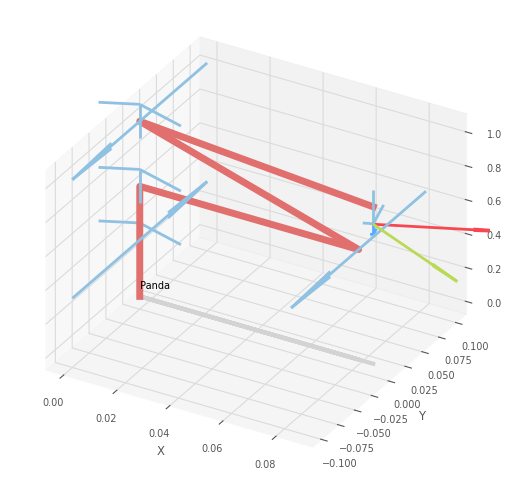

<Figure size 640x480 with 0 Axes>

In [41]:
q_start = [0, 0, 0, 0, 0, 0, 0]
robot.plot(q_start)
plt.show()

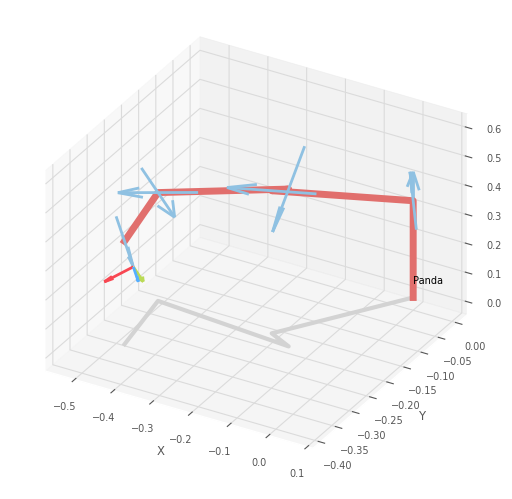

<Figure size 640x480 with 0 Axes>

In [42]:
q_end = [pi/4, -pi/3, -pi/4, pi/3, -pi/3, pi/4, pi/4]
robot.plot(q_end)
plt.show()

### 4. Plan the trajectory with prebuilt functions

In this step, we generate a smooth multi-axis trajectory in joint space. We utilize the `jtraj` function, which implements a **quintic (5th-order) polynomial** interpolation. This method is preferred for robot motion as it ensures:
*   **Continuous Velocity**: No sudden jumps in speed.
*   **Continuous Acceleration**: Zero jerk at the start and end points, which protects the robot's hardware (motors and reducers).

```python
# Number of steps
N = 100 
t_start = 0 
t_stop = 5 

# Time vector generation
time = np.linspace(t_start, t_stop, N) 

# Trajectory generation (jtraj returns q, qd, qdd)
# q: positions, qd: velocities, qdd: accelerations
tr = rtb.jtraj(q_start, q_end, time)

# Extracting the components for Newton-Euler analysis
q = tr.q
qd = tr.qd
qdd = tr.qdd


In [43]:
N = 100
t_start = 0
t_stop = 5
t_shag = t_stop/N
time = np.arange(t_start, t_stop, t_shag)
tr = rtb.jtraj(q_start, q_end, time)

q = tr.q
qd = tr.qd
qdd = tr.qdd

### 5. Solve the inverse dynamics


We solve the inverse dynamics to determine the torques $\tau$ required to execute the planned trajectory. We analyze three distinct scenarios using the **Recursive Newton-Euler Algorithm (RNEA)**:

1.  **Full Dynamics ($\dot{q} \neq 0, \ddot{q} \neq 0$):** Accounts for inertia, Coriolis/centripetal forces, gravity, and friction.
2.  **Quasi-Statics ($\dot{q} \neq 0, \ddot{q} \approx 0$):** Neglects acceleration-based inertial torques; useful for slow, constant-velocity movements.
3.  **Static Positioning ($\dot{q} = 0, \ddot{q} = 0$):** Calculates the gravity compensation torques ($G(q)$) needed to maintain the pose.

```python
# Scenario 1: Full Dynamics (Non-zero velocity and acceleration)
# tau: (7 x N) matrix of joint torques
tau_full = robot.rne(q, qd, qdd).T

# Scenario 2: Quasi-Statics (Non-zero velocity, zero acceleration)
# Accounts for C(q, qd) and G(q)
tau_quasi = robot.rne(q, qd, np.zeros((N, 7))).T

# Scenario 3: Static (Zero velocity, zero acceleration)
# Accounts only for G(q) - Gravity loading
tau_static = robot.rne(q, np.zeros((N, 7)), np.zeros((N, 7))).T


In [44]:
tau_full = robot.rne(q, qd, qdd).T

tau_quasi = robot.rne(q, qd, np.zeros((N, 7))).T

tau_static = robot.rne(q, np.zeros((N, 7)), np.zeros((N, 7))).T

### 6. Obtain the components of the dynamic equation


To analyze the contribution of each physical effect, we extract the numerical values of the matrices $M(q)$, $C(q, \dot{q})$, and $G(q)$ at each time step along the trajectory. 

*   **$M(q)$ (Inertia Matrix):** Represents the joint-space kinetic energy.
*   **$C(q, \dot{q})$ (Coriolis/Centripetal Matrix):** Captures non-linear coupling forces.
*   **$G(q)$ (Gravity Vector):** Represents the configuration-dependent weight of the links.




In [46]:
M = robot.inertia(q)
C = robot.coriolis(q, qd)
G = robot.gravload(q)

M0 = robot.inertia(q)
C0 = robot.coriolis(q, np.zeros([N,7]))
G0 = robot.gravload(q)

### 7. Plot the graphs

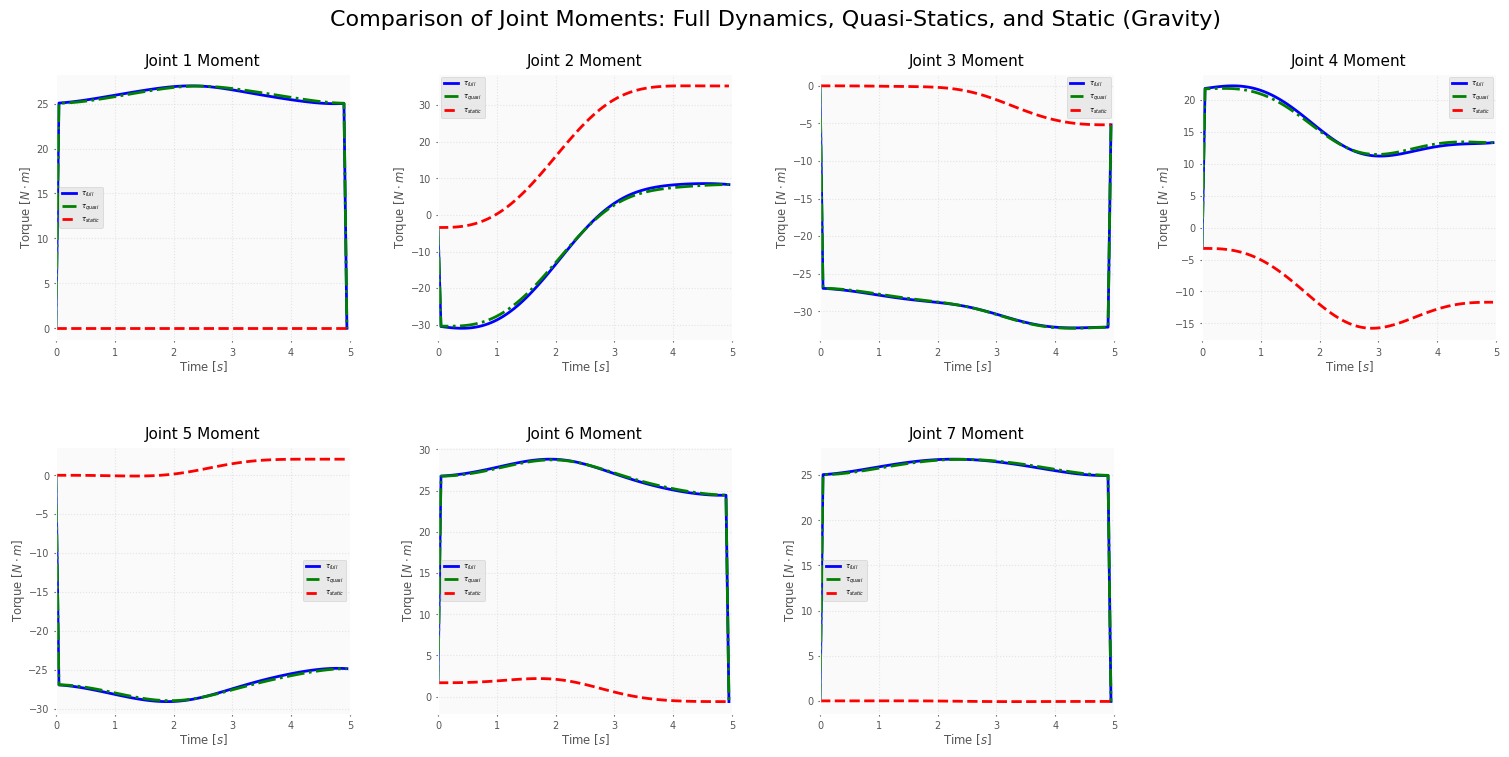

In [50]:
import matplotlib.pyplot as plt

# Set up canvas for 7 joints (2x4 grid)
plt.figure(figsize=(16, 8), dpi=100)
plt.subplots_adjust(left=0.05, bottom=0.1, right=0.95, top=0.9, wspace=0.3, hspace=0.4)

for g in range(7):
    plt.subplot(2, 4, g+1)
    
    # Scenario 1: Full Dynamics (blue)
    plt.plot(time, tau_full[g], linewidth=2, label=r"$\tau_{full}$", color='blue')
    
    # Scenario 2: Quasi-statics (green) 
    plt.plot(time, tau_quasi[g], linewidth=2, label=r"$\tau_{quasi}$", linestyle='-.', color='green')
    
    # Scenario 3: Static Scenario (red dashed)
    plt.plot(time, tau_static[g], linewidth=2, linestyle='--', label=r"$\tau_{static}$", color='red')
    
    plt.title(f"Joint {g+1} Moment", fontsize=11)
    plt.ylabel(r"Torque $[N \cdot m]$")
    plt.xlabel(r"Time $[s]$")
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.legend(fontsize='x-small') # Set to x-small to ensure it fits in the subplots
    
    ax = plt.gca()
    ax.set_facecolor((0.98, 0.98, 0.98)) 
    ax.set_xlim([t_start, t_stop])

# Updated title to include all three scenarios
plt.suptitle("Comparison of Joint Moments: Full Dynamics, Quasi-Statics, and Static (Gravity)", fontsize=16)
plt.show()



# Conclusions

Based on the inverse dynamics simulation of the **Franka Emika Panda** using the Recursive Newton-Euler Algorithm (RNEA), the following conclusions were formulated:

### 1. Dominance of the Gravity Component
The **Static scenario** ($\tau_{static}$, red dashed line) reveals that gravity is the primary source of joint torque for this manipulator. Joints supporting the largest mass segments (especially **Joint 2** and **Joint 4**) show significant static torques, reaching magnitudes over $30\text{ N}\cdot\text{m}$. Accurate gravity compensation is essential for the robot to maintain its pose without drifting.

### 2. Influence of Acceleration and Inertia
The difference between the **Full Dynamics** ($\tau_{full}$, blue line) and the **Quasi-Static** scenario ($\tau_{quasi}$, green line) represents the torque required to overcome the physical inertia of the links and drive systems ($[M(q) + G^2J_m]\ddot{q}$). In the generated 5-second trajectory, these lines are closely aligned, indicating that at moderate speeds, gravitational forces significantly outweigh inertial forces.

### 3. Impact of Velocity and Friction
The proximity of the **Full Dynamics** and **Quasi-Static** curves suggests that the **Coriolis/Centripetal forces** ($C(q, \dot{q})\dot{q}$) and **Viscous Friction** ($B\dot{q}$) are relatively low for the chosen trajectory. While these parameters were specified (e.g., $B=0.0015$, $\tau_c=0.4$), their total contribution to the dynamic load is secondary to the weight of the links.

### 4. Numerical Matrix Verification
The numerical extraction of the dynamic matrices at each time step confirmed the model's integrity:
*   The **Gravity Vector $G(q)$** matches the static torque values exactly.
*   The **Coriolis Matrix $C(q, \dot{q})$** elements remain negligible at low velocities.
*   The **Inertia Matrix $M(q)$** remains symmetric and positive-definite throughout the motion, ensuring physical feasibility.

### 5. Final Summary
The experiment confirms that for the Franka Emika Panda, a control strategy focused primarily on **Gravity Compensation** accounts for the majority of the motor effort during slow-to-moderate movements. However, the inclusion of the full dynamic model is necessary for high-speed motion to compensate for the inertial peaks seen during acceleration and deceleration phases.
